# Analytic disk

We create a Magritte model from an analytic description of a Keplerian disk (see e.g. [Homan et al. 2018](https://doi.org/10.1051/0004-6361/201732246); [Booth et al. 2019](https://doi.org/10.1051/0004-6361/201834388)).

## Setup

Import the required functionalty.

In [14]:
import magritte.setup    as setup                   # Model setup
import magritte.core     as magritte                # Core functionality
import magritte.mesher   as mesher                  # Mesher
import numpy             as np                      # Data structures
import warnings                                     # Hide warnings
warnings.filterwarnings('ignore')                   # especially for yt
import yt                                           # 3D plotting
import os

from tqdm                import tqdm                # Progress bars
from astropy             import units, constants    # Unit conversions
from scipy.spatial       import Delaunay, cKDTree   # Finding neighbors
from yt.funcs            import mylog               # To avoid yt output 
mylog.setLevel(40)                                  # as error messages

Define a working directory (you will have to change this; it must be an **absolute path**).

In [15]:
wdir = "/home/yasho379/magritte_rebuilt/tgs"

Create the working directory.

Define file names.

In [16]:
model_file = os.path.join(wdir, 'model_analytic_sphere_hcn.hdf5')   # Resulting Magritte model
lamda_file = os.path.join(wdir, 'hcn@hfs.modified.dat.txt'               )   # Line data file
bmesh_name = os.path.join(wdir, 'analytic_sphere'           )   # background mesh name (no extension!)

We use a data file that can be downloaded with the following links.

In [17]:
# lamda_link = "https://home.strw.leidenuniv.nl/~moldata/datafiles/p-nh3@loreau.dat"

Dowload the snapshot and the linedata (``%%capture`` is just used to suppress the output).

In [18]:
%%capture
#!wget $lamda_link --output-document $lamda_file

## Model parameters

The functions below describe the disk structure, based on the Magritte application presented in [De Ceuster et al. (2019)](https://doi.org/10.1093/mnras/stz3557).

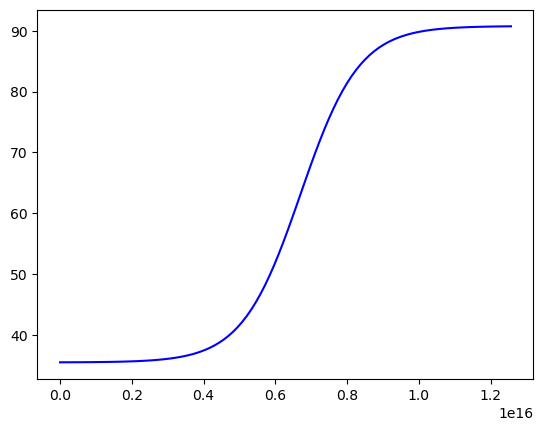

In [19]:
G      =           constants.G.si.value
kb     =           constants.k_B.si.value
m_H2   = 2.01588 * constants.u.si.value

#XCO    =  6.0e-4   # [.]
XHCN    =  5e-10   # [.]

T_cloud =  10 # [K]

rho_cloud = 1.0E4 * 1.0E6 * m_H2   # [kg/m^3]
r_out  =   (1000 * 4.84814e-6 * 140 *constants.pc.si.value)
r_in   =    1.0 * constants.au.si.value


def temperature(rr):
    return T_cloud # constant temperature cloud assumed for spectra generation
        
def radius(rr):
    """
    Returns the radius from the origin to the point rr in units of the model, usually AU
    """
    return (rr[0]**2. + rr[1]**2. + rr[2]**2.)**0.5


def density(rr):
    rho_0 = rho_cloud  # central density in si units
    r_0 = 47 * 4.84814e-6 * 140 *constants.pc.si.value #length scale in si units (47 arcsec at 140 pc)
    alpha =2.2   # power-law index
    r_max = r_out  # outer cutoff radius in AU

    # Compute radial distance
    Radius = radius(rr)
    # Calculate density profile
    GasDensity = rho_0 / (1.0 + (Radius / r_0)**alpha) + 500 * 1.0E6 * m_H2 # [kg/m^3]

    # Apply cutoff beyond r_out
    if hasattr(Radius, "__len__"):
        GasDensity[Radius > r_max] = 0.0
    else:
        if Radius > r_max:
            GasDensity = 0.0

    return GasDensity

def abn_nH2(rr):
    """
    H2 number density function.
    """
    return density(rr) / (2.01588 * constants.u.si.value)

def abn_nHCN(rr):
    """
    NH3 number density function.
    """
    return XHCN * abn_nH2(rr)

import numpy as np
import astropy.units as u
from astropy.constants import c

# Parameters with explicit units

#arsecond values assuming distance of 140 pc
rj = (320 * 4.84814e-6 * 140 *constants.pc.si.value)
d_rj = (78 * 4.84814e-6 * 140 *constants.pc.si.value)
r1 = (33 * 4.84814e-6 * 140 *constants.pc.si.value)
rV = (290 * 4.84814e-6 * 140 *constants.pc.si.value)
d_rV = (55 * 4.84814e-6 * 140 *constants.pc.si.value)

#values of velocity parameters 
sigma0 = (0.046 * 1000)
sigma_ext = (0.25 * 1000)
Vc = (-0.26 * 1000)

def velocity_r(rr):
    """
    Radial velocity profile V(r) [Eq. 5]
    r : astropy quantity with angular units (arcsec)
    Returns V in m/s
    """
    x, y, z = rr[0], rr[1], rr[2]
    r = np.sqrt(x**2 + y**2 + z**2)
    #v_radial = Vc * np.exp(-((r - rV)**2) / (2 * d_rV**2))
    v_radial = 1.5e-18*r
    if hasattr(r, "__len__"):
        v = np.zeros((3,) + r.shape)
        v[0] = v_radial * (x / r)
        v[1] = v_radial * (y / r)
        v[2] = v_radial * (z / r)
    else:
        v = np.array([v_radial * (x / r), v_radial * (y / r), v_radial * (z / r)])
    return v/3e8 # Convert to fraction of speed of light

def turbulence(rr):
    """
    Nonthermal velocity dispersion σ_nth(r) [Eq. 6]
    r : astropy quantity with angular units (arcsec)
    Returns σ_nth in m/s
    """
    r = radius(rr)
    term = (np.pi/2) + np.tanh(((r - rj)/d_rj))
    val = (sigma0 + (sigma_ext - sigma0)/np.pi * term)/2.3458
    return (val/(3e8))**2

def abn_nHCN(rr):
    """
    Abundance profile X(r) [Eq. 7]
    r : astropy quantity with angular units (arcsec)
    eta : scaling factor (unitless)
    Returns abundance (unitless)
    """
    r = radius(rr)
    return np.where(r < r1, XHCN*abn_nH2(rr), XHCN*abn_nH2(rr)*2) 

def plot_functions(positions):
    def function(r):
        term = (np.pi/2) + np.tanh(((r - rj)/d_rj))
        val = (sigma0 + (sigma_ext - sigma0)/np.pi * term)/2.3458
        return val
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    plt.plot(positions[0], function(positions[0]), label='Function', color='blue')

xs = np.linspace(0, 600 * 4.84814e-6 * 140 *constants.pc.si.value, 100)
ys = np.zeros_like(xs)
zs = np.zeros_like(xs)
positions = np.array([xs, ys, zs])
plot_functions(positions)





## Create background mesh

Define the desired background mesh, a ($75 \times 75 \times 75$) cube.

In [20]:
resolution = 75

xs = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)
ys = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)
zs = np.linspace(-r_out*1.1, +r_out*1.1, resolution, endpoint=True)

(Xs, Ys, Zs) = np.meshgrid(xs, ys, zs)

# Extract positions of points in background mesh
position = np.array((Xs.ravel(), Ys.ravel(), Zs.ravel())).T

# Evaluate the density on the cube
rhos      = density([Xs, Ys, Zs])
rhos_min  = np.min(rhos[rhos!=0.0])
rhos     += rhos_min

Now we remesh this model using the new remesher

In [21]:
positions_reduced, nb_boundary = mesher.remesh_point_cloud(position, rhos.ravel(), max_depth=10, threshold= 2e-1, hullorder=4)

new interior points:  26960
number boundary points:  1538


We add a spherical inner boundary at 0.01*r_out

In [22]:
healpy_order = 5 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(positions_reduced, nb_boundary, 0.01*r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))
print("number of boundary points: ", nb_boundary)

number of points in reduced grid:  28797
number of boundary points:  1838


We add a spherical outer boundary at r_out

In [23]:
healpy_order = 15 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(positions_reduced, nb_boundary, r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))

number of points in reduced grid:  15257


In [24]:
npoints = len(positions_reduced)

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(positions_reduced)
(indptr, indices) = delaunay.vertex_neighbor_vertices
neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(npoints)]
nbs       = [n for sublist in neighbors for n in sublist]
n_nbs     = [len(sublist) for sublist in neighbors]

# Convenience arrays
zeros = np.zeros(npoints)
ones  = np.ones (npoints)

Convert model functions to arrays based the model mesh.

In [25]:
position = positions_reduced
velocity = np.array([velocity_r (rr) for rr in positions_reduced])
nH2      = np.array([abn_nH2    (rr) for rr in positions_reduced])
nHCN      = np.array([abn_nHCN   (rr) for rr in positions_reduced])
tmp      = np.array([temperature(rr) for rr in positions_reduced])
trb      = np.array([turbulence (rr) for rr in positions_reduced])



## Create model

Now all data is read, we can use it to construct a Magritte model.

<div class="alert alert-warning">

Warning

Since we do not aim to do self-consistent non-LTE simulations in these examples, we only consider the first radiative transition of CO (J=1-0). To consider all transitions, use `setup.set_linedata_from_LAMDA_file` as in the commented line below it.
We also only consider 2 rays here (up and down the direction we want to image). To consider all directions, comment out the indecated lines and use `setup.set_uniform_rays` as in the commented line below.
    
</div>

In [26]:
model = magritte.Model ()                              # Create model object

model.parameters.set_model_name         (model_file)   # Magritte model file
model.parameters.set_dimension          (3)            # This is a 3D model
model.parameters.set_npoints            (npoints)      # Number of points
model.parameters.set_nrays              (2)            # Number of rays  
model.parameters.set_nspecs             (3)            # Number of species (min. 5)
model.parameters.set_nlspecs            (1)            # Number of line species
model.parameters.set_nquads             (51)           # Number of quadrature points

model.geometry.points.position.set(position)
model.geometry.points.velocity.set(velocity)

model.geometry.points.  neighbors.set(  nbs)
model.geometry.points.n_neighbors.set(n_nbs)

model.chemistry.species.abundance = np.array((nHCN, nH2, zeros)).T
model.chemistry.species.symbol    = ['HCN', 'H2', 'e-']

model.thermodynamics.temperature.gas  .set(tmp)
model.thermodynamics.turbulence.vturb2.set(trb)

model.parameters.set_nboundary(nb_boundary)
model.geometry.boundary.boundary2point.set(np.arange(nb_boundary))

direction = np.array([[+1,0,0], [-1,0,0]])            # Comment out to use all directions
model.geometry.rays.direction.set(direction)          # Comment out to use all directions
model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

# setup.set_uniform_rays            (model)   # Uncomment to use all directions

#setup.set_boundary_condition_CMB  (model)
setup.set_boundary_condition_zero  (model)
#setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [0,1]})  # Consider only CO lines
setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
setup.set_quadrature              (model)

model.write()



[1, 2, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[2, 3, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[3, 3, 2, 1.1755e-11, 1.451e-11, 2.0467e-11, 2.5878e-11, 3.4489e-11, 4.0699e-11, 4.7042e-11, 5.321e-11, 5.6657e-11, 6.0231e-11, 6.2102e-11, 6.3373e-11]
[4, 4, 1, 3.0351e-11, 2.4556e-11, 2.2104e-11, 2.199e-11, 2.2275e-11, 2.2357e-11, 2.2198e-11, 2.1662e-11, 2.1068e-11, 1.9999e-11, 1.9138e-11, 1.845e-11]
[5, 4, 2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[6, 4, 3, 2.6121e-11, 3.2245e-11, 4.5481e-11, 5.7507e-11, 7.6642e-11, 9.0441e-11, 1.0454e-10, 1.1824e-10, 1.259e-10, 1.3385e-10, 1.38e-10, 1.4083e-10]
[7, 5, 1, 1.3061e-11, 1.6123e-11, 2.2741e-11, 2.8753e-11, 3.8321e-11, 4.5221e-11, 5.2269e-11, 5.9122e-11, 6.2952e-11, 6.6923e-11, 6.9002e-11, 7.0415e-11]
[8, 5, 2, 1.5699e

Writing thermodynamics...
Writing temperature...
Writing turbulence...
Writing lines...
Writing lineProducingSpecies...
Writing linedata...
ncolpoar = 1
--- colpoar = 0
Writing collisionPartner...
(l, c) = 0, 0
Writing quadrature...
Writing populations...
Writing radiation...
Writing frequencies...


## Plot model

Load the data in a `yt` unstructured mesh.

In [27]:
ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nHCN[delaunay.simplices].astype(np.float64)}
)

Plot a slice through the mesh orthogonal to the z-axis and x-axis.


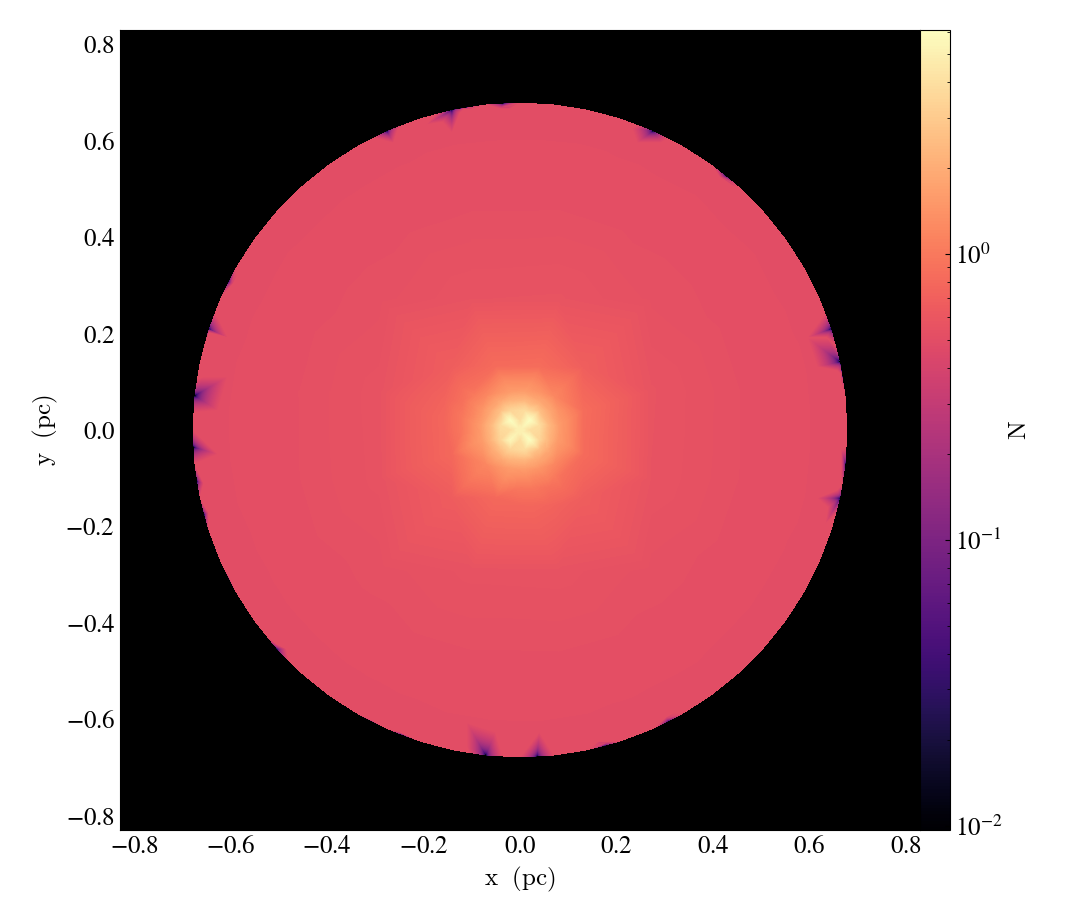

In [28]:
sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)


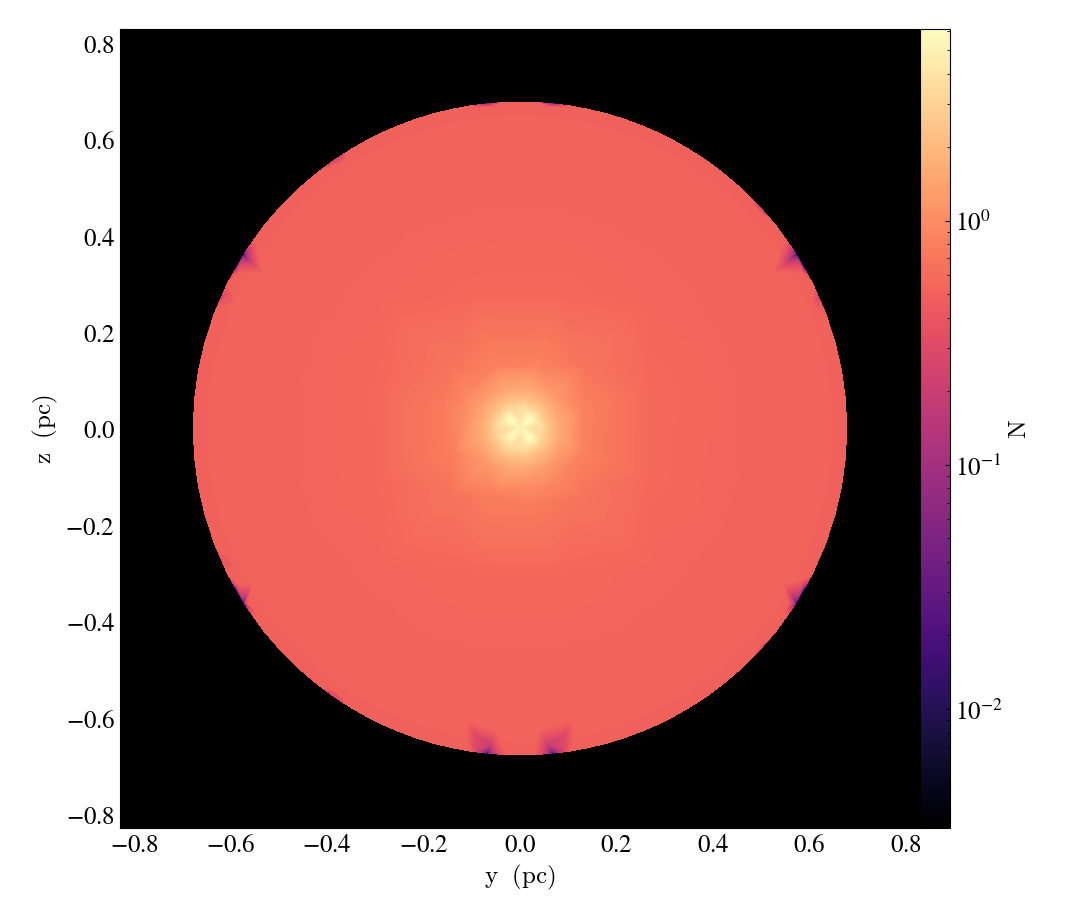

In [29]:
sl = yt.SlicePlot (ds, 'x', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)

Show meshes on the plots.


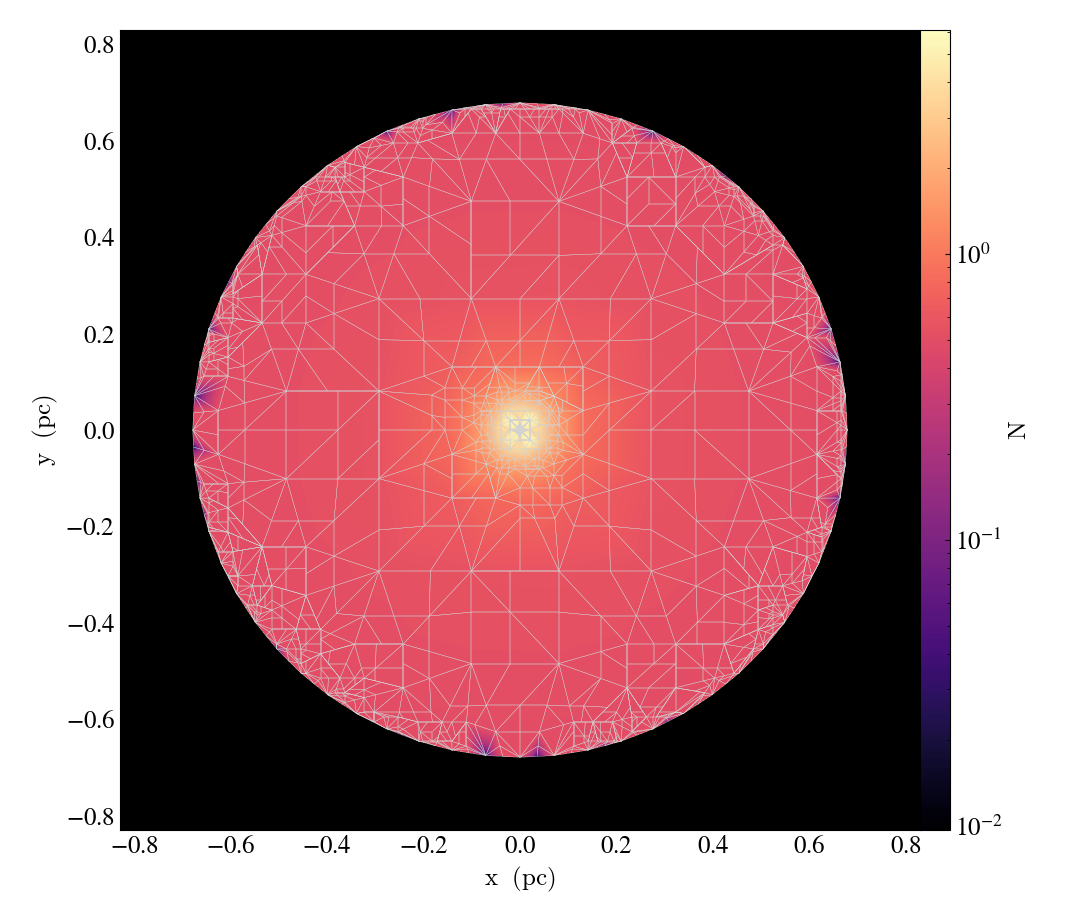

In [30]:
sl = yt.SlicePlot      (ds, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})


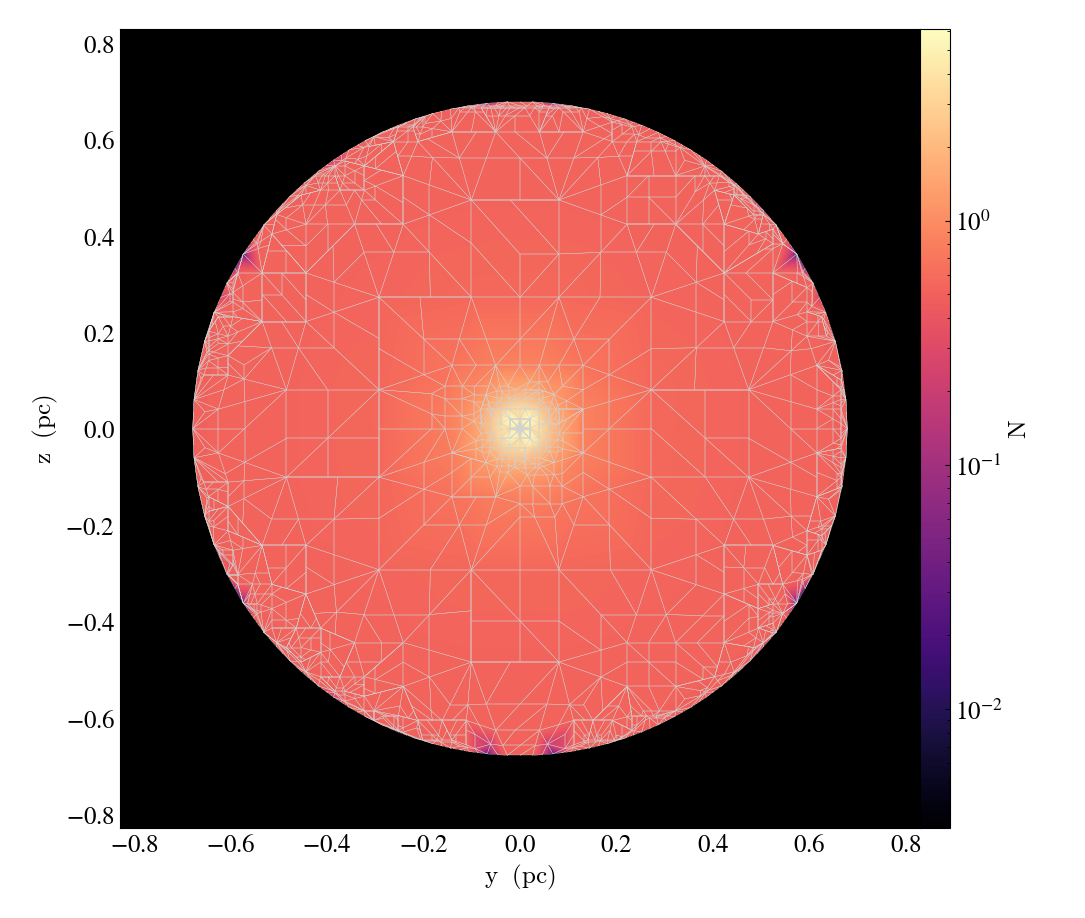

In [31]:
sl = yt.SlicePlot      (ds, 'x', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (0.9)
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})